In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [18]:
## Graph State
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    score: float

In [6]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title
    title = state['title']

    # prompt
    prompt = f'Generate a detailed outline for a blog on the topic  - {title}'
    outline = model.invoke(prompt).content

    state['outline'] = outline

    # llm call, gen outline

    return state


In [8]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content
    
    return state

In [22]:
def evalute_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    content = state['content']

    prompt = f"Based on this outline {outline}. \n Rate this blog {content} and Generate a score that is a integer number. only output a score value"
    score = model.invoke(prompt).content
    print(score)
    state['score'] =  score
    return state


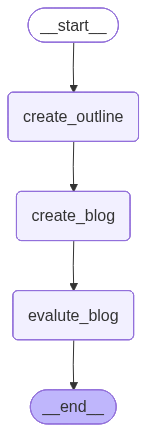

In [23]:
## Define Graph
graph = StateGraph(BlogState)

# Nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evalute_blog', evalute_blog)

# Edge
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evalute_blog')
graph.add_edge('evalute_blog', END)

# compile
workflow = graph.compile()
workflow

In [24]:
# execution
init_state = {'title': 'RISE OF AI in India'}
final_state = workflow.invoke(init_state)
final_state

8


{'title': 'RISE OF AI in India',
 'outline': 'Here is a detailed outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Introduction to the Indian context: why AI is crucial for India\'s economic growth and development\n* Thesis statement: India is rapidly embracing AI, and its rise is transforming various industries and sectors, presenting both opportunities and challenges.\n\n**II. Current State of AI in India**\n\n* Overview of the current AI landscape in India: key players, initiatives, and investments\n* Discussion of the Indian government\'s role in promoting AI: policies, regulations, and funding\n* Examples of successful AI implementations in India: e.g., chatbots, virtual assistants, predictive analytics\n\n**III. Key Drivers of AI Adoption in India**\n\n* **Demographics**: India\'s large and young population, and the potential for AI to address demographic challen

In [25]:
print(final_state['score'])

8


In [16]:
print(final_state['content'])

**The Rise of AI in India: A New Era of Innovation and Growth**

Artificial Intelligence (AI) has been transforming the world at an unprecedented pace, driving economic growth, innovation, and societal transformation. As a key player in the global economy, India is rapidly emerging as a hub for AI adoption and innovation, with significant investments, initiatives, and applications across various sectors. In this blog, we will delve into the current state of AI in India, explore the key drivers of its growth, and examine the various applications, success stories, and challenges that lie ahead.

**Current State of AI in India**

India's AI ecosystem is thriving, with a growing number of startups, research institutions, and government initiatives driving innovation and adoption. The National AI Strategy, announced in 2018, outlines a comprehensive framework for AI development, focusing on areas such as healthcare, education, and infrastructure. The AI Task Force, established in 2017, has 